**Carga de liberias**

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as ticker


**Carga de CSV con los que vamos a trabajar los datos del EDA**

In [ ]:
antiguedad = pd.read_csv("../src/result/antiguitat_tipus_vehicle.csv")
poblacion = pd.read_csv("../src/result/poblacion.csv")
renta = pd.read_csv("../src/result/renta_distritos.csv")
tipos = pd.read_csv("../src/result/tipus_vehicle.csv")
endolls = pd.read_csv("../src/result/endolls.csv")

---

- **Densidad de Vehículos:** ¿Cuál es el ratio de vehículos por habitante en cada distrito? (Ej: `Total Vehículos / Población`). ¿Hay distritos con más coches que personas?

1. El caso de Les Corts y Sarrià-Sant Gervasi (Ratio Alto)

El Sant Gervasi la barra de población no es tan alta como L'Example pero en cambio la densidad de vehiculos es alta

Ratio: Aquí el ratio es el más elevado. Hay muchos vehículos por cada habitante. Esto confirma que son zonas de renta alta con mayor motorización privada o distritos con muchas sedes corporativas (especialmente en Les Corts/Diagonal).

2. `El fenómeno de Sant Martí`
Es muy interesante ver cómo Sant Martí, siendo un distrito con población media-alta, tiene un pico de vehículos casi tan alto como el Eixample.
Sant Martí es una zona industrial/tecnológica, asi que podría ser renting/flota de empresas.

3. `Los distritos **"Sostenibles"**:` Ciutat Vella y Gràcia
En Ciutat Vella, la línea roja está en su punto más bajo. Es el distrito con menos vehículos por habitante.

Ratio: Encontramos que en Sant Gervasi casi cada persona tiene un vehiculo 0.82, mientras que en Ciutat Vella menos de 1 de cada 2 tiene vehiculo.

In [6]:
poblacion = poblacion.merge(renta, how="left", on=["Nom_Districte",])
poblacion = poblacion.drop("Unnamed: 0", axis=1)

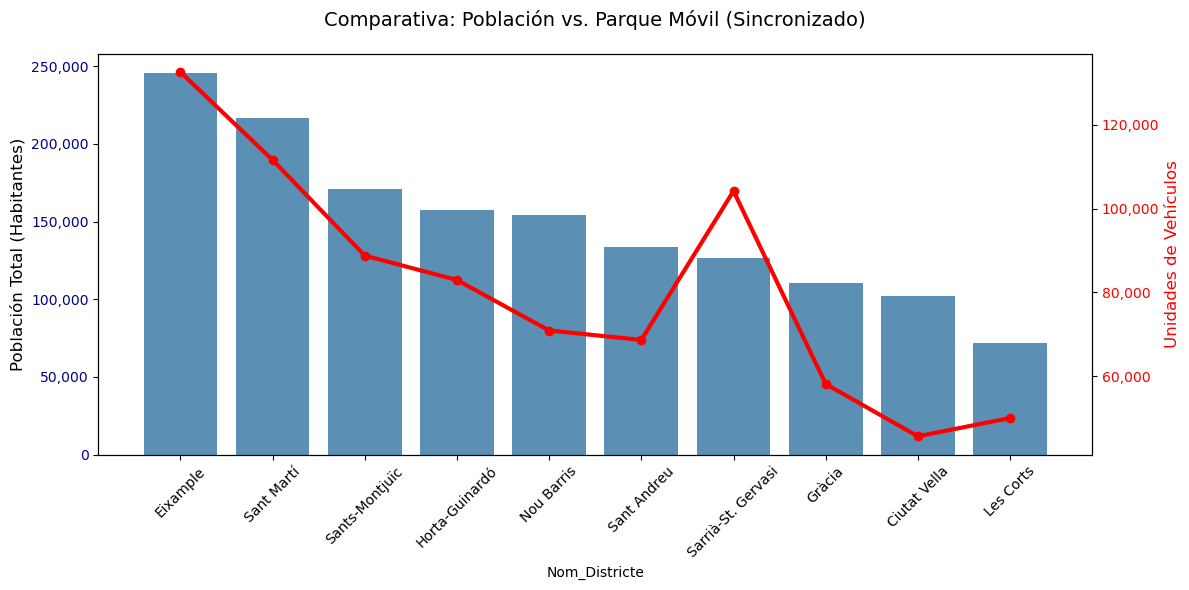

In [ ]:
df_pob_sum = poblacion.groupby("Nom_Districte")["Valor"].sum().sort_values(ascending=False)
orden_distritos = df_pob_sum.index
df_veh_sum = tipos.groupby("Nom_Districte")["Unidades"].sum().reindex(orden_distritos)

fig, ax1 = plt.subplots(figsize=(12, 6))

sns.barplot(
    x=orden_distritos, 
    y=df_pob_sum.values, 
    ax=ax1, 
    alpha=0.8,
)

ax1.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, p: format(int(x), ',')))
ax1.set_ylabel("Población Total (Habitantes)", fontsize=12)
ax1.tick_params(axis='y', labelcolor='darkblue')
ax1.tick_params(axis='x', rotation=45)
ax2 = ax1.twinx()

ax2.plot(
    orden_distritos, 
    df_veh_sum.values, 
    marker="o", 
    color="red", 
    linewidth=3, 
    label="Total Vehículos"
)

ax2.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, p: format(int(x), ',')))
ax2.set_ylabel("Unidades de Vehículos", fontsize=12, color="red")
ax2.tick_params(axis='y', labelcolor='red')
ax2.grid(False) 

plt.title("Comparativa: Población vs. Parque Móvil (Sincronizado)", fontsize=14, pad=20)
fig.tight_layout()
plt.show()

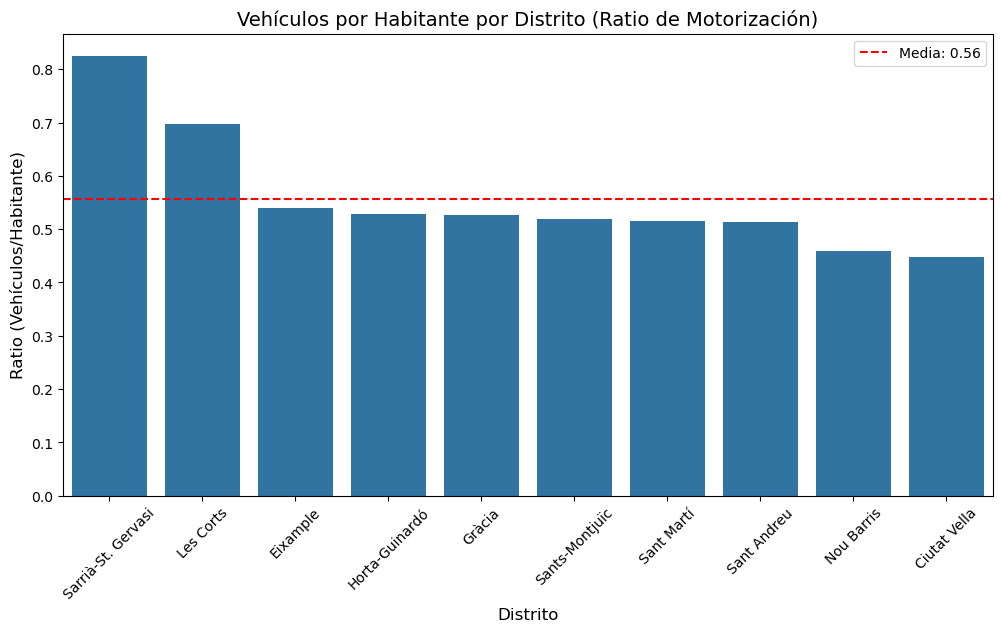

In [8]:
total_vehiculos = tipos.groupby("Nom_Districte")["Unidades"].sum()
total_poblacion = poblacion.groupby("Nom_Districte")["Valor"].sum()
df_ratio = (total_vehiculos / total_poblacion).sort_values(ascending=False).reset_index()
df_ratio.columns = ["Distrito", "Ratio"]
media_global = df_ratio["Ratio"].mean()
plt.figure(figsize=(12, 6))
sns.barplot(data=df_ratio, x="Distrito", y="Ratio")
plt.axhline(media_global, color="red", linestyle="--", label=f"Media: {media_global:.2f}")

plt.title("Vehículos por Habitante por Distrito (Ratio de Motorización)", fontsize=14)
plt.ylabel("Ratio (Vehículos/Habitante)", fontsize=12)
plt.xlabel("Distrito", fontsize=12)
plt.xticks(rotation=45)
plt.legend()
plt.show()

In [9]:
df_ratio

,Distrito,Ratio
0,Sarrià-St. Gervasi,0.825432
1,Les Corts,0.697140
2,Eixample,0.539526
3,Horta-Guinardó,0.527493
4,Gràcia,0.525976
5,Sants-Montjuïc,0.519870
6,Sant Martí,0.514463
7,Sant Andreu,0.512615
8,Nou Barris,0.458791
9,Ciutat Vella,0.448186


1. Contexto Demográfico y Económico
Población por Distrito: Volumen total de habitantes (barras de base).

Renta Media: Nivel adquisitivo de cada zona (línea de referencia económica).

Pregunta clave: ¿Cómo se distribuye la riqueza en Barcelona según el padrón?


---
Desigualdad marcada: La línea roja muestra que la riqueza se concentra en Sarrià y Les Corts, mientras que Nou Barris y Ciutat Vella quedan muy por debajo de la media de la ciudad.

El motor demográfico: El Eixample destaca como el distrito clave, al combinar la mayor población de Barcelona con una renta superior al promedio.

Brecha de movilidad: Los distritos con barras altas y renta baja enfrentan el mayor reto para renovar sus vehículos frente a las restricciones de la ZBE.


In [10]:
print(f"Barcelona tiene {poblacion['Valor'].sum()} habitantes de +18 años, con una renta media de {poblacion['Import_Euros'].mean().round(2)}€")

Barcelona tiene 1489500 habitantes de +18 años, con una renta media de 22221.53€


2. Radiografía del Parque Móvil
Volumen Total: Cuántos vehículos hay en cada distrito.

Ratio de Motorización: El cálculo de Vehículos / Personas (Saturación).

Antigüedad del Parque: Proporción de coches viejos vs. nuevos (Gráfico apilado al 100%).

Pregunta clave: ¿Qué distritos tienen los coches más viejos y cuáles están más saturados de vehículos?


Eixample, el distrito más grande: Es el distrito con más vehículos totales, liderando tanto en coches nuevos como en antiguos; su volumen es tan grande que domina cualquier estadística de la ciudad.

La Brecha de la ZBE: Mientras que en Sarrià la renovación es constante (más bloques azules y naranjas), en Nou Barris y Horta-Guinardó casi la mitad del parque móvil es antiguo (bloque verde), lo que los hace mucho más vulnerables a las restricciones ambientales.

Renta del distrito: Existe una correlación total entre el bolsillo y la edad del vehiculo; los distritos con rentas bajas están "atrapados" con vehículos viejos, demostrando que la transición al coche eléctrico es, ante todo, una cuestión de capacidad económica.

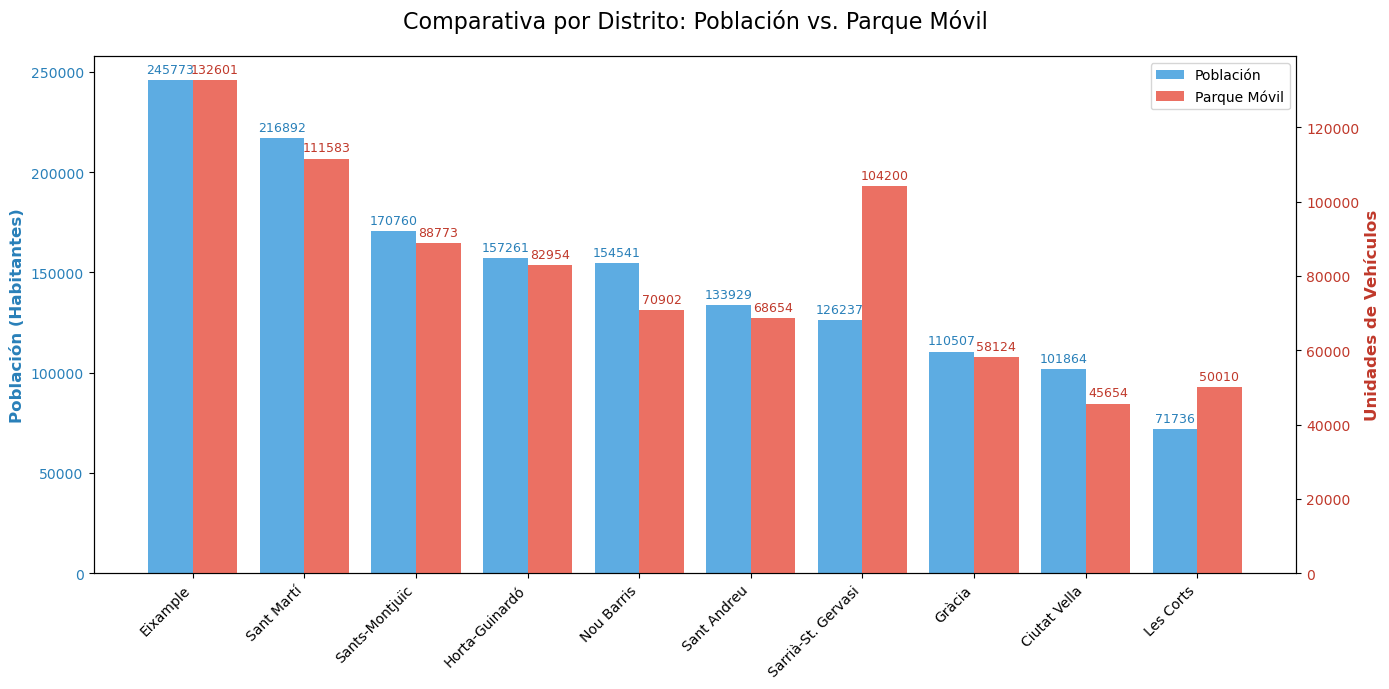

In [11]:
df_pob = poblacion.groupby("Nom_Districte")["Valor"].sum()
df_veh = tipos.groupby("Nom_Districte")["Unidades"].sum()

orden_distritos = df_pob.sort_values(ascending=False).index

pob_values = df_pob.reindex(orden_distritos)
veh_values = df_veh.reindex(orden_distritos)

fig, ax1 = plt.subplots(figsize=(14, 7))
x = np.arange(len(orden_distritos))
width = 0.4 

bar1 = ax1.bar(x - width/2, pob_values, width, label='Población', color='#3498db', alpha=0.8)
ax1.set_ylabel("Población (Habitantes)", fontsize=12, color="#2980b9", fontweight='bold')
ax1.tick_params(axis='y', labelcolor="#2980b9")

ax2 = ax1.twinx()
bar2 = ax2.bar(x + width/2, veh_values, width, label='Parque Móvil', color='#e74c3c', alpha=0.8)
ax2.set_ylabel("Unidades de Vehículos", fontsize=12, color="#c0392b", fontweight='bold')
ax2.tick_params(axis='y', labelcolor="#c0392b")

ax1.set_xticks(x)
ax1.set_xticklabels(orden_distritos, rotation=45, ha='right')
ax1.set_title("Comparativa por Distrito: Población vs. Parque Móvil", fontsize=16, pad=20)

ax1.bar_label(bar1, padding=3, fmt='%g', fontsize=9, color='#2980b9')
ax2.bar_label(bar2, padding=3, fmt='%g', fontsize=9, color='#c0392b')

ax2.grid(False)
fig.tight_layout()

lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines + lines2, labels + labels2, loc='upper right')

plt.show()

In [12]:
def categorizar(antiguitat):
    if antiguitat in ["Menys d'un any d'antiguitat", "1 any", "2 anys", "3 anys", "4 anys"]:
        return "Nuevos (0-4)"
    elif antiguitat in ["5 anys", "6 anys", "7 anys", "8 anys", "9 anys", "10 anys"]:
        return "Medios (5-10)"
    elif antiguitat in ["D'11 a 20 anys", "Més de 20 anys"]:
        return "Antiguos (>10)"
    else:
        return "No consta"
antiguedad['categorias'] = antiguedad['Antiguitat'].apply(categorizar)

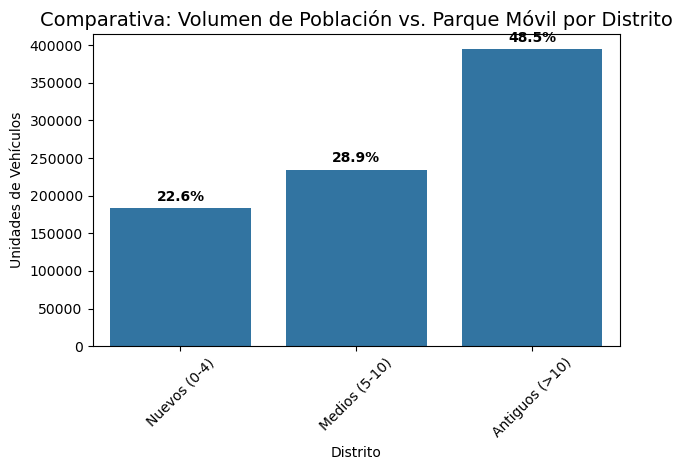

In [13]:
# 1. Filtramos los datos primero y lo guardamos en una variable para facilitar los cálculos
df_filtrado = antiguedad[antiguedad['categorias'] != "No consta"]

# 2. Calculamos el total de todos los vehículos (para poder sacar el %)
total_vehiculos = df_filtrado['Valor'].sum()

# 3. Creamos el gráfico y lo asignamos a 'ax'
ax = sns.barplot(data=df_filtrado, x="categorias", y="Valor", errorbar=None, estimator=sum)

# 4. Añadimos las etiquetas con los porcentajes
for container in ax.containers:
    # Obtenemos el valor numérico de cada barra
    valores = container.datavalues
    # Calculamos el porcentaje para cada valor y le damos formato de 1 decimal seguido del símbolo %
    etiquetas = [f'{(valor / total_vehiculos) * 100:.1f}%' for valor in valores]
    # Colocamos las etiquetas en las barras
    ax.bar_label(container, labels=etiquetas, padding=3, weight='bold')

# 5. Configuración de títulos y etiquetas
plt.title("Comparativa: Volumen de Población vs. Parque Móvil por Distrito", fontsize=14)
plt.ylabel("Unidades de Vehículos")
plt.xlabel("Distrito") # Nota: Quizás quieras cambiar esto a "Categoría" o "Antigüedad"
plt.xticks(rotation=45) 

plt.tight_layout()
plt.show()

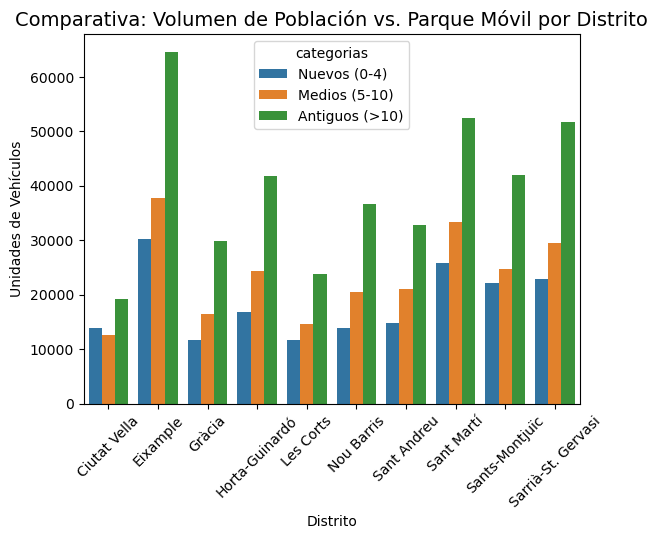

In [14]:
sns.barplot(antiguedad[antiguedad['categorias'] != "No consta"],x="Nom_Districte",y="Valor", hue="categorias", errorbar=None, estimator=sum)
plt.title("Comparativa: Volumen de Población vs. Parque Móvil por Distrito", fontsize=14)
plt.ylabel("Unidades de Vehículos")
plt.xlabel("Distrito")
plt.xticks(rotation=45) 
plt.show()

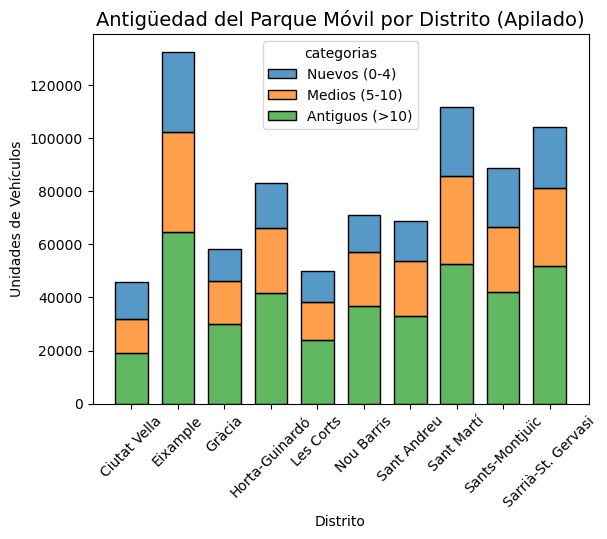

In [15]:
sns.histplot(antiguedad[antiguedad['categorias'] != "No consta"],x="Nom_Districte",weights="Valor",hue="categorias",shrink=0.7,multiple="stack")
plt.title("Antigüedad del Parque Móvil por Distrito (Apilado)", fontsize=14)
plt.ylabel("Unidades de Vehículos")
plt.xlabel("Distrito")
plt.xticks(rotation=45)

plt.show()

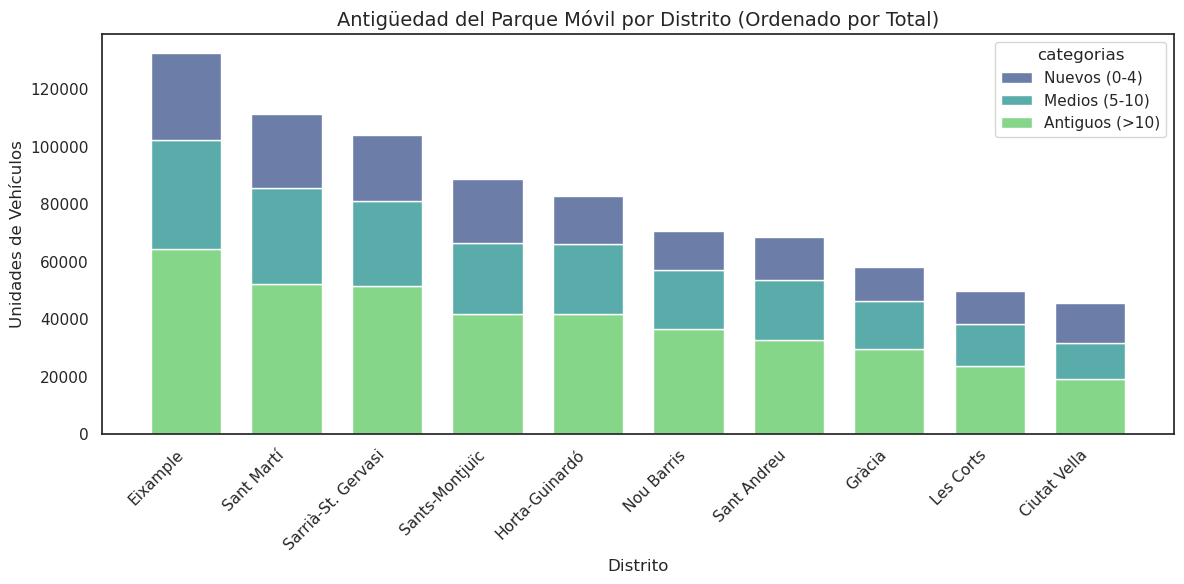

In [ ]:
df_filtrado = antiguedad[antiguedad['categorias'] != "No consta"].copy()

orden_distritos = (
    df_filtrado.groupby("Nom_Districte")["Valor"]
    .sum()
    .sort_values(ascending=False)
    .index
)

df_filtrado["Nom_Districte"] = pd.Categorical(
    df_filtrado["Nom_Districte"], 
    categories=orden_distritos, 
    ordered=True
)

plt.figure(figsize=(12, 6))
sns.histplot(
    data=df_filtrado,
    x="Nom_Districte",
    weights="Valor",
    hue="categorias",
    # Definimos el orden de las capas (opcional, de nuevo a viejo)
    hue_order=["Nuevos (0-4)", "Medios (5-10)", "Antiguos (>10)"],
    shrink=0.7,
    multiple="stack",
    palette="viridis"
)

plt.title("Antigüedad del Parque Móvil por Distrito (Ordenado por Total)", fontsize=14)
plt.ylabel("Unidades de Vehículos")
plt.xlabel("Distrito")
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

3. El salto a la sostenibilidad . Combustión vs Electricos/Hibridos

Infraestructura de Carga (Endolls): Localización de los puntos de carga públicos y privados.

Correlación Renta-Eléctrico: Gráfico de dispersión para visualizar la "Brecha Eléctrica".

Pregunta clave: ¿Están los cargadores donde realmente están los coches eléctricos o donde hay más renta?

In [17]:
endolls = endolls.rename(columns={"Distrito": "Nom_Districte"})
endolls.drop("Unnamed: 0", axis=1, inplace=True)

/tmp/ipykernel_31209/3304967527.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=endolls, y="tipo", palette='viridis', order=order)


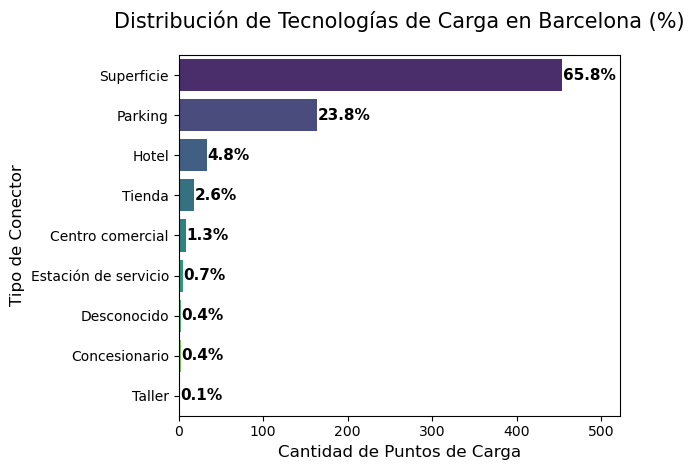

In [18]:
order = endolls['tipo'].value_counts().index
ax = sns.countplot(data=endolls, y="tipo", palette='viridis', order=order)

total = len(endolls['tipo'])
for p in ax.patches:
    percentage = '{:.1f}%'.format(100 * p.get_width() / total)
    x = p.get_width() + 0.5
    y = p.get_y() + p.get_height() / 2
    ax.annotate(percentage, (x, y), fontsize=11, fontweight='bold', va='center')

plt.title("Distribución de Tecnologías de Carga en Barcelona (%)", fontsize=15, pad=20)
plt.xlabel("Cantidad de Puntos de Carga", fontsize=12)
plt.ylabel("Tipo de Conector", fontsize=12)

plt.xlim(0, max(endolls['tipo'].value_counts()) * 1.15)

plt.tight_layout()
plt.show()

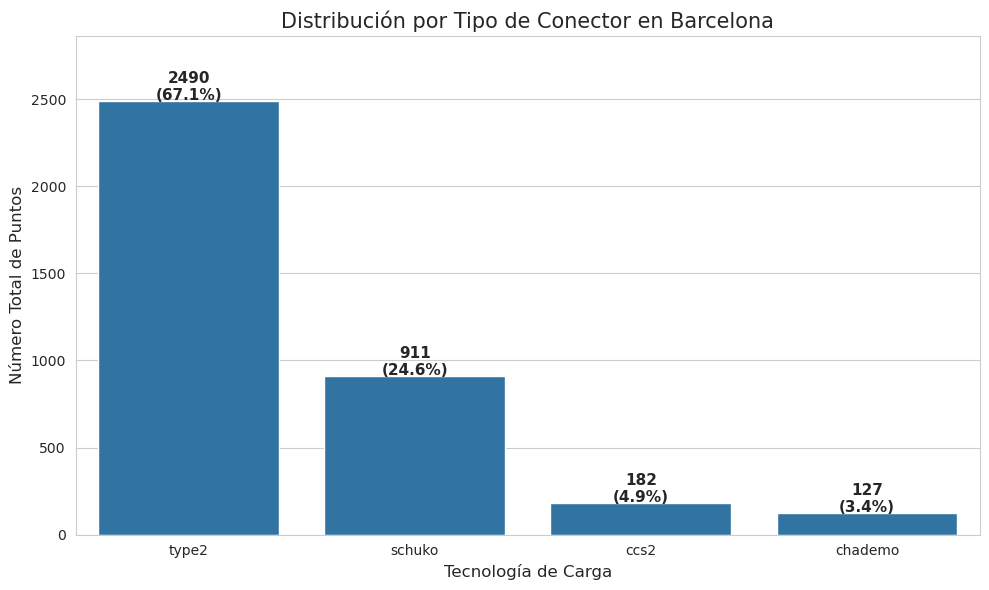

In [19]:
totales_conectores = endolls[['type2', 'schuko', 'ccs2', 'chademo']].sum().sort_values(ascending=False)
df_tipos = totales_conectores.reset_index()
df_tipos.columns = ['Tipo_Conector', 'Cantidad']
plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")

ax = sns.barplot(data=df_tipos, x='Tipo_Conector', y='Cantidad')

total_global = df_tipos['Cantidad'].sum()
for p in ax.patches:
    height = p.get_height()
    percentage = '{:.1f}%'.format(100 * height / total_global)
    ax.annotate(f'{int(height)}\n({percentage})',(p.get_x() + p.get_width() / 2., height), ha = 'center', va = 'center', xytext = (0, 10), textcoords = 'offset points',fontsize=11, fontweight='bold')

plt.title("Distribución por Tipo de Conector en Barcelona", fontsize=15)
plt.ylabel("Número Total de Puntos", fontsize=12)
plt.xlabel("Tecnología de Carga", fontsize=12)
plt.ylim(0, df_tipos['Cantidad'].max() * 1.15)
plt.tight_layout()
plt.show()

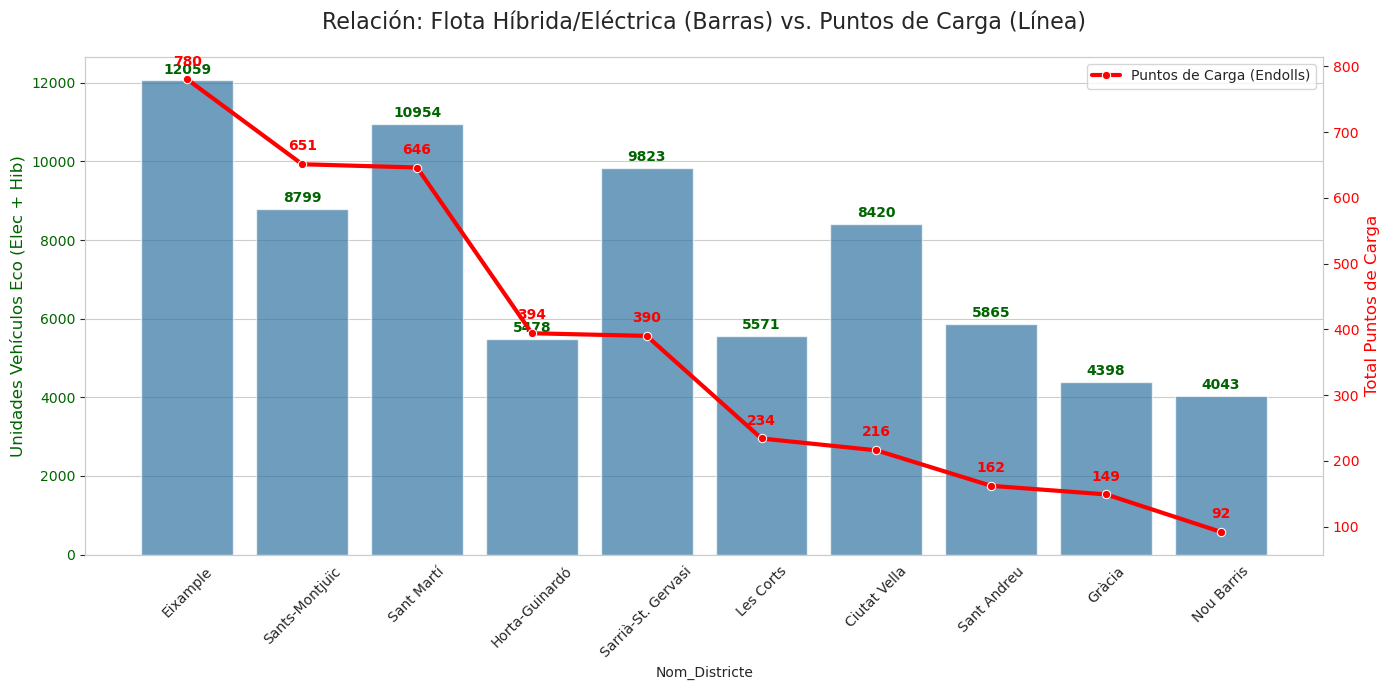

In [20]:

motores_eco = ['Eléctrica', 'Hibrido'] 
tipos_filtrados = tipos[tipos['Tipus_Propulsio'].isin(motores_eco)].copy()
orden_distritos = endolls.groupby('Nom_Districte')['total_punts'].sum().sort_values(ascending=False).index
df_barras = tipos_filtrados.groupby("Nom_Districte")["Unidades"].sum().reindex(orden_distritos).reset_index()
df_puntos_linea = endolls.groupby('Nom_Districte')['total_punts'].sum().reindex(orden_distritos).reset_index()
fig, ax1 = plt.subplots(figsize=(14, 7))
sns.barplot(df_barras, x="Nom_Districte", y="Unidades", ax=ax1, order=orden_distritos, alpha=0.7
)
for p in ax1.patches:
    if p.get_height() > 0:
        ax1.annotate(f'{int(p.get_height())}', 
                     (p.get_x() + p.get_width() / 2., p.get_height()), 
                     ha='center', va='baseline', 
                     fontsize=10, color='darkgreen', fontweight='bold',
                     xytext=(0, 5), textcoords='offset points')

ax1.set_ylabel("Unidades Vehículos Eco (Elec + Hib)", fontsize=12, color='darkgreen')
ax1.tick_params(axis='y', labelcolor='darkgreen', labelsize=10)
ax1.tick_params(axis='x', rotation=45)

ax2 = ax1.twinx()
sns.lineplot(df_puntos_linea, x="Nom_Districte", y="total_punts", ax=ax2, marker="o", color="red", linewidth=3, sort=False,label="Puntos de Carga (Endolls)"
)
for x, y in enumerate(df_puntos_linea["total_punts"]):
    if not pd.isna(y):
        ax2.annotate(f'{int(y)}', 
                     (x, y), 
                     textcoords="offset points", 
                     xytext=(0, 10), 
                     ha='center', 
                     fontsize=10, color='red', fontweight='bold')
ax2.set_ylabel("Total Puntos de Carga", fontsize=12, color="red")
ax2.tick_params(axis='y', labelcolor='red')
ax2.grid(False) 
plt.title("Relación: Flota Híbrida/Eléctrica (Barras) vs. Puntos de Carga (Línea)", fontsize=16, pad=20)
fig.tight_layout()
plt.show()

In [21]:

total_eco_ciudad = df_barras['Unidades'].sum()

df_barras['%_sobre_total'] = (df_barras['Unidades'] / total_eco_ciudad) * 100
print(df_barras[['Nom_Districte', 'Unidades', '%_sobre_total']])

        Nom_Districte  Unidades  %_sobre_total
0            Eixample     12059      15.991248
1      Sants-Montjuïc      8799      11.668214
2          Sant Martí     10954      14.525925
3      Horta-Guinardó      5478       7.264289
4  Sarrià-St. Gervasi      9823      13.026124
5           Les Corts      5571       7.387614
6        Ciutat Vella      8420      11.165628
7         Sant Andreu      5865       7.777483
8              Gràcia      4398       5.832118
9          Nou Barris      4043       5.361358


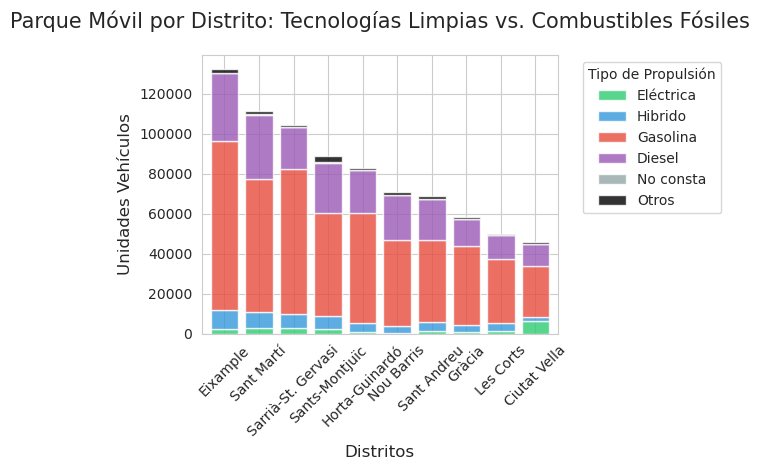

In [ ]:

df_plot = tipos.groupby(['Nom_Districte', 'Tipus_Propulsio'])['Unidades'].sum().unstack()

nuevo_orden = ['Eléctrica', 'Hibrido', 'Gasolina', 'Diesel', 'No consta', 'Otros']

df_plot = df_plot.reindex(columns=[col for col in nuevo_orden if col in df_plot.columns])

# --- COLORES ---
colores_propulsion = {
    'Eléctrica': '#2ecc71',  # Verde
    'Hibrido': '#3498db',    # Azul
    'Gasolina': '#e74c3c',   # Rojo
    'Diesel': '#9b59b6',     # Lila
    'No consta': '#95a5a6',  # Gris
    'Otros': '#000000'       # Negro
}

lista_colores = [colores_propulsion[col] for col in df_plot.columns]

df_plot['Total'] = df_plot.sum(axis=1)
df_plot = df_plot.sort_values('Total', ascending=False).drop(columns='Total')

ax = df_plot.plot(
    kind='bar', 
    stacked=True, 
    alpha=0.8, 
    width=0.8, 
    color=lista_colores,
)

plt.title("Parque Móvil por Distrito: Tecnologías Limpias vs. Combustibles Fósiles", fontsize=15, pad=20)
plt.xlabel("Distritos", fontsize=12)
plt.ylabel("Unidades Vehículos", fontsize=12)
plt.xticks(rotation=45)
plt.legend(title="Tipo de Propulsión", bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()


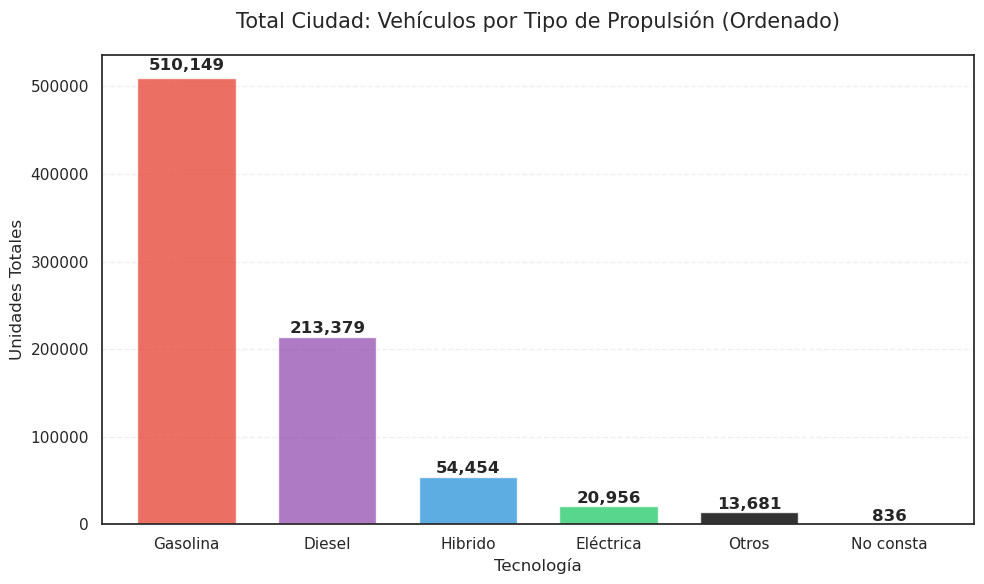

In [ ]:
df_total = tipos.groupby('Tipus_Propulsio')['Unidades'].sum().sort_values(ascending=False)

lista_colores = [colores_propulsion.get(col, '#95a5a6') for col in df_total.index]

plt.figure(figsize=(10, 6))
ax = df_total.plot(kind='bar', color=lista_colores, alpha=0.8, width=0.7)

for i, v in enumerate(df_total):
    ax.text(i, v + (v * 0.01), f'{int(v):,}', ha='center', va='bottom', fontweight='bold')


plt.title("Total Ciudad: Vehículos por Tipo de Propulsión (Ordenado)", fontsize=15, pad=20)
plt.ylabel("Unidades Totales")
plt.xlabel("Tecnología")
plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
df_resumen = df_plot.copy()

columnas_eco = [c for c in ['Eléctrica', 'Hibrido'] if c in df_resumen.columns]
df_resumen['Total_Eco'] = df_resumen[columnas_eco].sum(axis=1)

df_resumen['Total_Vehiculos'] = df_resumen.sum(axis=1)
df_resumen['Total_Resto'] = df_resumen['Total_Vehiculos'] - df_resumen['Total_Eco']

# 3. Calculamos los porcentajes
df_resumen['%_Eco'] = (df_resumen['Total_Eco'] / df_resumen['Total_Vehiculos']) * 100
df_resumen['%_Resto'] = (df_resumen['Total_Resto'] / df_resumen['Total_Vehiculos']) * 100

# Ordenamos por los distritos con mayor penetración de coches Eco
df_resumen = df_resumen.sort_values('%_Eco', ascending=False)

# Mostramos el resultado
print(df_resumen[['Total_Eco', 'Total_Resto', '%_Eco']])

Tipus_Propulsio     Total_Eco  Total_Resto      %_Eco
Nom_Districte                                        
Ciutat Vella             8420        45654  15.571254
Les Corts                5571        50010  10.023209
Sants-Montjuïc           8799        88773   9.017956
Sant Martí              10954       111583   8.939341
Sarrià-St. Gervasi       9823       104200   8.614929
Eixample                12059       132601   8.336098
Sant Andreu              5865        68654   7.870476
Gràcia                   4398        58124   7.034324
Horta-Guinardó           5478        82954   6.194590
Nou Barris               4043        70902   5.394623


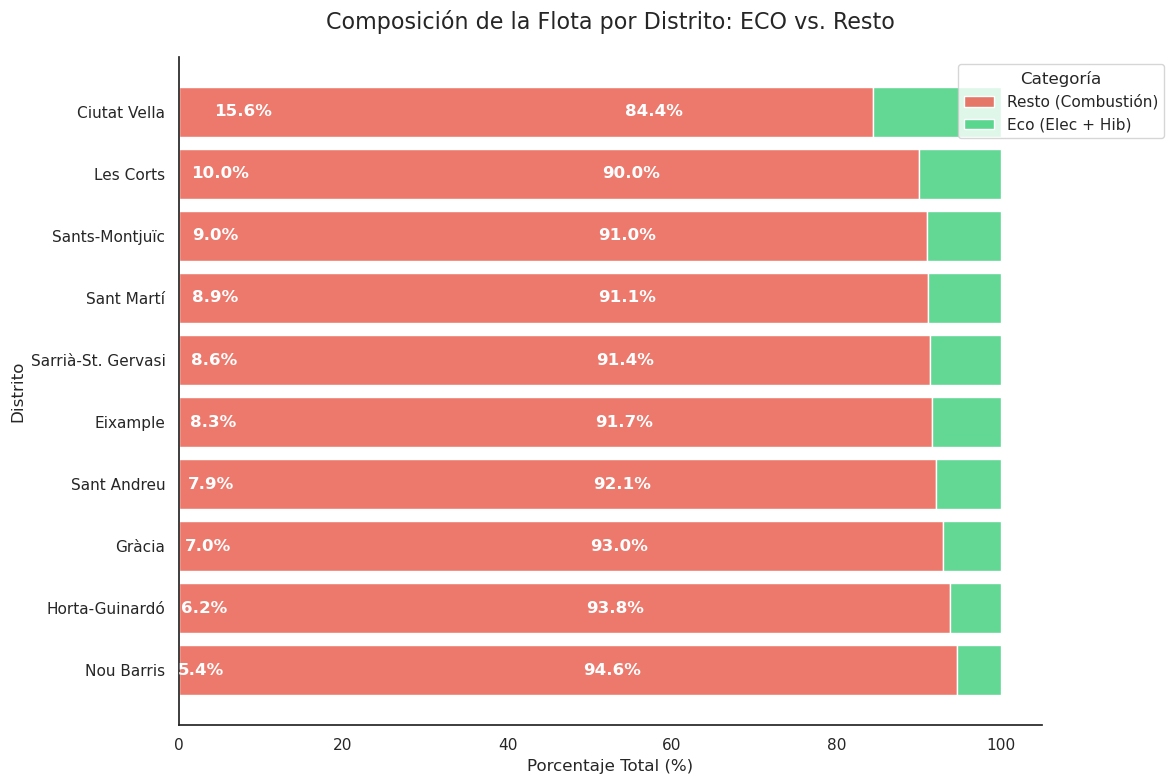

In [ ]:

df_melt = df_resumen[['%_Eco', '%_Resto']].reset_index().melt(
    id_vars='Nom_Districte', 
    var_name='Tipo_Propulsion', 
    value_name='Porcentaje'
)

sns.set_theme(style="white")
plt.figure(figsize=(12, 8))

ax = sns.histplot(
    data=df_melt,
    y='Nom_Districte',
    weights='Porcentaje',
    hue='Tipo_Propulsion',
    multiple='stack',
    palette={'%_Eco': '#2ecc71', '%_Resto': '#e74c3c'},
    shrink=0.8
)

for i, distrito in enumerate(df_resumen.index):
    # Porcentaje Eco (Verde)
    pct_eco = df_resumen.loc[distrito, '%_Eco']
    if pct_eco > 5: # Solo dibujamos si hay espacio
        plt.text(pct_eco / 2, i, f'{pct_eco:.1f}%', 
                 va='center', ha='center', color='white', fontweight='bold')
    
    # Porcentaje Resto (Rojo)
    pct_resto = df_resumen.loc[distrito, '%_Resto']
    if pct_resto > 5:
        plt.text(pct_eco + (pct_resto / 2), i, f'{pct_resto:.1f}%', 
                 va='center', ha='center', color='white', fontweight='bold')

# 5. Personalización final
plt.title("Composición de la Flota por Distrito: ECO vs. Resto", fontsize=16, pad=20)
plt.xlabel("Porcentaje Total (%)", fontsize=12)
plt.ylabel("Distrito", fontsize=12)
plt.legend(title="Categoría", labels=['Resto (Combustión)', 'Eco (Elec + Hib)'], 
           loc='upper right', bbox_to_anchor=(1.15, 1))

sns.despine()
plt.tight_layout()
plt.show()

4. Conclusiones y "Anomalías" detectadas
El Caso Ciutat Vella: Desconexión entre residentes y flotas de empresas (muchos coches, poca renta).

Vulnerabilidad ZBE: Identificación de distritos que sufrirán más las restricciones por tener parques móviles antiguos y rentas bajas (ej. Nou Barris).

Eficiencia de Infraestructura: Distritos que necesitan un refuerzo urgente de puntos de carga.

Desigualdad Socioeconómica: Existe una correlación directa entre renta alta y adopción de vehículos eco. Nou Barris (renta baja) cierra la lista en todas las métricas, confirmando una transición desigual.

Carga Privada vs. Pública: En distritos de élite como Sarrià-Sant Gervasi, la infraestructura pública es baja pese a la alta renta, lo que sugiere un fuerte predominio del cargador privado en garajes propios.

El Motor del Eixample: Se consolida como el epicentro de la movilidad eléctrica, liderando en vehículos, puntos de carga y actividad.

Obsolescencia Tecnológica: Aunque domina el estándar europeo (Type 2), el 25% de la red sigue siendo de carga lenta (Schuko), lo que limita la agilidad de la infraestructura pública actual.

Conclusión: La "Brecha Eléctrica" en Barcelona no es solo de vehículos, sino de infraestructura adaptada al nivel adquisitivo de cada distrito.